<a href="https://colab.research.google.com/github/dreach329/CUNY_LaGuardia_HF_Analytics_Course/blob/main/Python_Project_2_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [4]:
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.shape

(101766, 50)

In [ ]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [6]:
dfrace = df[['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'A1Cresult', 'readmitted']]

In [7]:
dfrace.head()

,encounter_id,patient_nbr,race,gender,age,weight,A1Cresult,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,NaN,NO
1,149190,55629189,Caucasian,Female,[10-20),?,NaN,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,NaN,NO
3,500364,82442376,Caucasian,Male,[30-40),?,NaN,NO
4,16680,42519267,Caucasian,Male,[40-50),?,NaN,NO


In [8]:
dfrace['race'].value_counts()

,count
race,
Caucasian,76099
AfricanAmerican,19210
?,2273
Hispanic,2037
Other,1506
Asian,641


In [21]:
comparison = pd.crosstab(dfrace['race'], dfrace['readmitted'])
display(comparison)

readmitted,<30,>30,NO
race,,,
?,188,538,1547
AfricanAmerican,2155,6634,10421
Asian,65,161,415
Caucasian,8592,27124,40383
Hispanic,212,642,1183
Other,145,446,915


In [22]:
df1 = dfrace.assign(race='Asian')
df2 = dfrace.assign(race='AfricanAmerican')
df3 = dfrace.assign(race='Caucasian')

combined = pd.concat([df1, df2, df3])

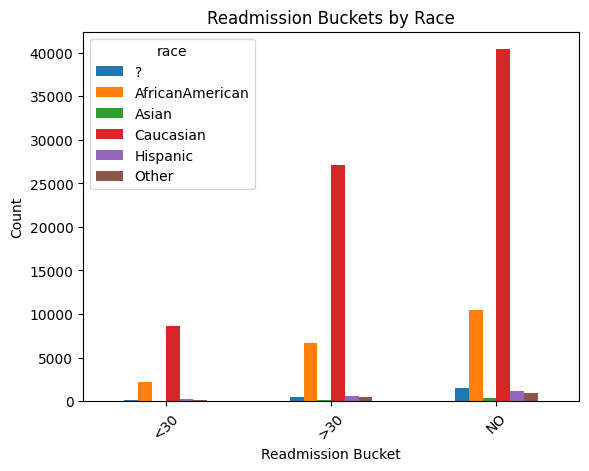

In [20]:
ct.plot(kind='bar')

plt.title('Readmission Buckets by Race')
plt.xlabel('Readmission Bucket')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

In [43]:
comparison = pd.crosstab(dfrace['race'], dfrace['age'])
display(comparison)

age,[0-10),[10-20),[20-30),[30-40),[40-50),[50-60),[60-70),[70-80),[80-90),[90-100)
race,,,,,,,,,,
?,1,9,46,76,220,361,495,599,397,69
AfricanAmerican,16,209,540,1223,2787,4225,4232,3816,1817,345
Asian,2,2,6,15,52,123,160,180,90,11
Caucasian,136,438,975,2203,6131,11835,16693,20761,14602,2325
Hispanic,2,23,63,174,337,403,489,386,141,19
Other,4,10,27,84,158,309,414,326,150,24


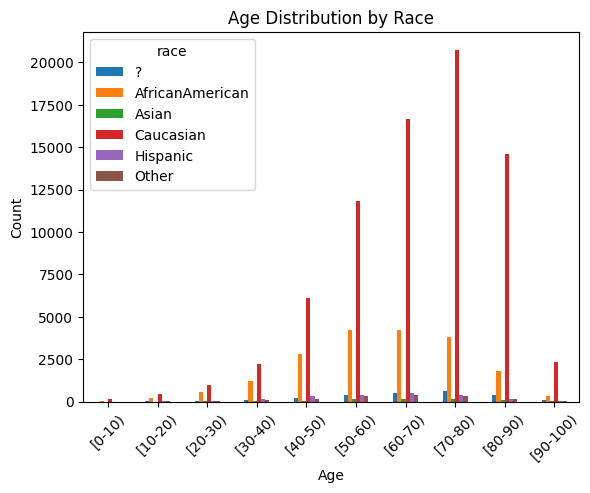

In [49]:
comparison.T.plot(kind='bar')

plt.title('Age Distribution by Race')
plt.xlabel('Age')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [46]:
comparison2 = combined.groupby(['race', 'age'])['readmitted'].value_counts()
display(comparison2)

race             age       readmitted
AfricanAmerican  [0-10)    NO             132
                           >30             26
                           <30              3
                 [10-20)   NO             427
                           >30            224
                                         ... 
Caucasian        [80-90)   >30           6223
                           <30           2078
                 [90-100)  NO            1675
                           >30            808
                           <30            310
Name: count, Length: 90, dtype: int64

In [54]:
df1=df[df['race'].isin(['AfricanAmerican','Caucasian'])]
display(df1)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


<Axes: xlabel='race,age'>

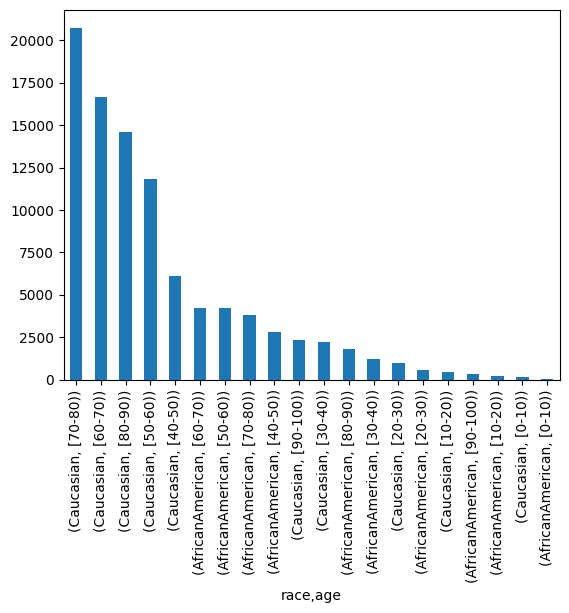

In [59]:
df1[['race', 'age']].value_counts().plot(kind='bar')

In [62]:
ct = pd.crosstab(df1['race'], df1['age'])
display(ct)

age,[0-10),[10-20),[20-30),[30-40),[40-50),[50-60),[60-70),[70-80),[80-90),[90-100)
race,,,,,,,,,,
AfricanAmerican,16,209,540,1223,2787,4225,4232,3816,1817,345
Caucasian,136,438,975,2203,6131,11835,16693,20761,14602,2325


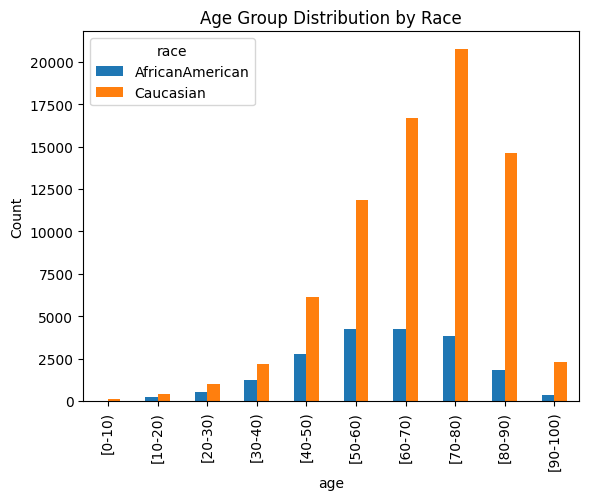

In [63]:
ct.T.plot(kind='bar')

plt.title('Age Group Distribution by Race')
plt.ylabel('Count')

plt.show()

In [ ]:
AfricanAmericans and Caucasians have highest rate of diabetes. Although Asians have a lower rate of Diabetes, the readmnission rate is simliar across all races. Highest rate of diabetes are in the 50-80 age group.